In [10]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [11]:
data_path_1 = Path('../data/processed/train_ready.csv')
data_path_2 = Path('../data/processed/train_catastro.csv')

df_ready = pd.read_csv(data_path_1)
df_catastro = pd.read_csv(data_path_2)

print(f"train_ready: {df_ready.shape}")
print(f"train_catastro: {df_catastro.shape}")

train_ready: (665, 22)
train_catastro: (665, 23)


# RandomForest Test — Predicción de Abandono de Vivienda

**Objetivo:** Entrenar modelos Random Forest para predecir abandono de vivienda (abandono_alto) usando datos del Censo INEGI y datos catastrales.

**Datasets:**
- `train_ready.csv`: Indicadores de rezago, bienestar y actividad económica (DENUE)
- `train_catastro.csv`: Igual que anterior + valor catastral máximo

**Métrica de alineación:** Recall > 0.85 (minimizar falsos negativos — no dejar zonas en riesgo sin detectar)

In [26]:
def preprocess_data(df):
    df_clean = df.drop(columns=['Unnamed: 0'], errors='ignore')
    X = df_clean.drop(columns=['abandono_alto'])
    y = df_clean['abandono_alto']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, X.columns.tolist()

In [17]:
X_tr_1, X_te_1, y_tr_1, y_te_1, features_1 = preprocess_data(df_ready)
X_tr_2, X_te_2, y_tr_2, y_te_2, features_2 = preprocess_data(df_catastro)

print(f"train_ready after preprocessing: {X_tr_1.shape}")
print(f"train_catastro after preprocessing: {X_tr_2.shape}")
print(f"Features: {len(features_1)} vs {len(features_2)}")

train_ready after preprocessing: (532, 20)
train_catastro after preprocessing: (532, 21)
Features: 20 vs 21


In [18]:
def train_and_evaluate(X_train, X_test, y_train, y_test, dataset_name):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_pred_proba = rf.predict_proba(X_test)[:, 1]
    
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    results = {
        'Dataset': dataset_name,
        'Recall': recall, 'F1-Score': f1, 'AUC-ROC': auc,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Precisión': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'n_features': X_train.shape[1], 'n_test': len(y_test)
    }
    return results, rf, y_pred, y_pred_proba

In [30]:
results_1, model_1, pred_1, proba_1 = train_and_evaluate(X_tr_1, X_te_1, y_tr_1, y_te_1, 'train_ready')
results_2, model_2, pred_2, proba_2 = train_and_evaluate(X_tr_2, X_te_2, y_tr_2, y_te_2, 'train_catastro')

In [20]:
df_results = pd.DataFrame([results_1, results_2])
display(df_results.round(4))

,Dataset,Recall,F1-Score,AUC-ROC,TP,FP,FN,TN,Precisión,n_features,n_test
0,train_ready,0.0455,0.0645,0.7680,1,8,21,103,0.1111,20,133
1,train_catastro,0.0455,0.0667,0.7811,1,7,21,104,0.1250,21,133


In [27]:
print("MODELO ALTERNATIVO: RandomForest con class_weight='balanced'\n")

def train_balanced(X_train, X_test, y_train, y_test, dataset_name):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, 
                                max_depth=15, class_weight='balanced')
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_pred_proba = rf.predict_proba(X_test)[:, 1]
    
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    return {
        'Dataset': dataset_name,
        'Recall': recall, 'F1-Score': f1, 'AUC-ROC': auc,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Precisión': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Predicciones_Positivas': y_pred.sum()
    }

results_balanced_1 = train_balanced(X_tr_1, X_te_1, y_tr_1, y_te_1, 'train_ready (balanced)')
results_balanced_2 = train_balanced(X_tr_2, X_te_2, y_tr_2, y_te_2, 'train_catastro (balanced)')

df_balanced = pd.DataFrame([results_balanced_1, results_balanced_2])
print(df_balanced.round(4))

print(f"\nMEJORA CON CLASS_WEIGHT:")
print(f"train_ready: Recall {results_1['Recall']:.3f} → {results_balanced_1['Recall']:.3f}")
print(f"train_catastro: Recall {results_2['Recall']:.3f} → {results_balanced_2['Recall']:.3f}")

MODELO ALTERNATIVO: RandomForest con class_weight='balanced'

                     Dataset  Recall  F1-Score  AUC-ROC  TP  FP  FN   TN  \
0     train_ready (balanced)  0.0909    0.1176   0.7181   2  10  20  101   
1  train_catastro (balanced)  0.0455    0.0667   0.7455   1   7  21  104   

   Precisión  Predicciones_Positivas  
0     0.1667                      12  
1     0.1250                       8  

MEJORA CON CLASS_WEIGHT:
train_ready: Recall 0.045 → 0.091
train_catastro: Recall 0.045 → 0.045


In [37]:
print("MODELO ALTERNATIVO: Ajuste de Threshold (usando balanced model)\n")
print("Exploramos diferentes umbrales de decisión para el modelo balanceado:\n")

def evaluate_threshold(y_true, y_pred_proba, threshold, dataset_name):
    y_pred = (y_pred_proba >= threshold).astype(int)
    if y_pred.sum() == 0 or y_pred.sum() == len(y_pred):
        return None
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Threshold': threshold,
        'Recall': recall,
        'Precisión': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'TP': tp, 'FP': fp, 'FN': fn,
        'Predicciones_Pos': y_pred.sum()
    }

# Re-entrenar con balanced para obtener probabilidades
rf_balanced_1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, 
                                       max_depth=15, class_weight='balanced')
rf_balanced_1.fit(X_tr_1, y_tr_1)
proba_balanced_1 = rf_balanced_1.predict_proba(X_te_1)[:, 1]

thresholds = [0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
results_threshold = []
for t in thresholds:
    result = evaluate_threshold(y_te_1.values, proba_balanced_1, t, f'Threshold={t}')
    if result:
        results_threshold.append(result)

df_threshold = pd.DataFrame(results_threshold)
print(df_threshold.round(4))



MODELO ALTERNATIVO: Ajuste de Threshold (usando balanced model)

Exploramos diferentes umbrales de decisión para el modelo balanceado:

   Threshold  Recall  Precisión  TP  FP  FN  Predicciones_Pos
0       0.10  0.9091     0.2740  20  53   2                73
1       0.20  0.6818     0.2885  15  37   7                52
2       0.25  0.4091     0.2308   9  30  13                39
3       0.30  0.3182     0.2258   7  24  15                31
4       0.35  0.2727     0.2500   6  18  16                24
5       0.40  0.1364     0.1875   3  13  19                16
6       0.45  0.0909     0.1429   2  12  20                14
7       0.50  0.0909     0.1667   2  10  20                12


In [33]:
print("BÚSQUEDA DE HIPERPARÁMETROS CON GRIDSEARCH\n")
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

print(f"Grid search con {len(param_grid)} parámetros...")
print(f"Combinaciones totales: ~{50*5*3*3*2} (se prueban en paralelo)\n")

# GridSearch solo en train_ready para ahorrar tiempo
rf_grid = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_grid, 
    param_grid, 
    cv=5, 
    scoring='recall',  # Optimizamos por Recall (métrica crítica)
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr_1, y_tr_1)

print(f"\n{'='*70}")
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"{'='*70}")
print(f"\nParams: {grid_search.best_params_}")
print(f"Best CV Recall Score: {grid_search.best_score_:.4f}")

# Entrenar modelo con mejores parámetros
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_te_1)
y_pred_proba_best = best_rf.predict_proba(X_te_1)[:, 1]

recall_best = recall_score(y_te_1, y_pred_best)
f1_best = f1_score(y_te_1, y_pred_best)
auc_best = roc_auc_score(y_te_1, y_pred_proba_best)
tn, fp, fn, tp = confusion_matrix(y_te_1, y_pred_best).ravel()

results_best = {
    'Dataset': 'train_ready (GridSearch Optimizado)',
    'Recall': recall_best,
    'F1-Score': f1_best,
    'AUC-ROC': auc_best,
    'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    'Precisión': tp / (tp + fp) if (tp + fp) > 0 else 0
}

print(f"\nRESULTADOS EN TEST SET:")
print(f"  Recall: {recall_best:.4f} (Modelo base: {results_1['Recall']:.4f})")
print(f"  F1-Score: {f1_best:.4f} (Modelo base: {results_1['F1-Score']:.4f})")
print(f"  AUC-ROC: {auc_best:.4f} (Modelo base: {results_1['AUC-ROC']:.4f})")
print(f"  Predicciones positivas: {y_pred_best.sum()} (base: {pred_1.sum()})")

BÚSQUEDA DE HIPERPARÁMETROS CON GRIDSEARCH

Grid search con 5 parámetros...
Combinaciones totales: ~4500 (se prueban en paralelo)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits

MEJORES HIPERPARÁMETROS ENCONTRADOS:

Params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Recall Score: 0.6444

RESULTADOS EN TEST SET:
  Recall: 0.5000 (Modelo base: 0.0455)
  F1-Score: 0.3188 (Modelo base: 0.0645)
  AUC-ROC: 0.7199 (Modelo base: 0.7680)
  Predicciones positivas: 47 (base: 9)


In [46]:
print("COMPARATIVA: MODELO ORIGINAL vs GRIDSEARCH OPTIMIZADO\n")
print("="*70)

comparison_data = [
    {
        'Modelo': 'RandomForest Original',
        'Recall': results_1['Recall'],
        'F1-Score': results_1['F1-Score'],
        'AUC-ROC': results_1['AUC-ROC'],
        'Precisión': results_1['Precisión'],
        'TP': results_1['TP'],
        'FN': results_1['FN'],
        'FP': results_1['FP'],
        'Parámetros': 'n_est=100, max_depth=15, random_state=42'
    },
    {
        'Modelo': 'RandomForest GridSearch',
        'Recall': results_best['Recall'],
        'F1-Score': results_best['F1-Score'],
        'AUC-ROC': results_best['AUC-ROC'],
        'Precisión': results_best['Precisión'],
        'TP': results_best['TP'],
        'FN': results_best['FN'],
        'FP': results_best['FP'],
        'Parámetros': 'n_est=100, max_depth=5, class_weight=balanced, min_leaf=4'
    }
]

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

COMPARATIVA: MODELO ORIGINAL vs GRIDSEARCH OPTIMIZADO

                 Modelo   Recall  F1-Score  AUC-ROC  Precisión  TP  FN  FP                                                Parámetros
  RandomForest Original 0.045455  0.064516 0.768018   0.111111   1  21   8                  n_est=100, max_depth=15, random_state=42
RandomForest GridSearch 0.500000  0.318841 0.719902   0.234043  11  11  36 n_est=100, max_depth=5, class_weight=balanced, min_leaf=4


### Falla 1 — Desbalance de clases

El Recall bajo se explica por la estructura desbalanceada del target: ~83% negativos vs ~17% positivos. La siguiente celda muestra un gráfico de barras con conteos y porcentajes.

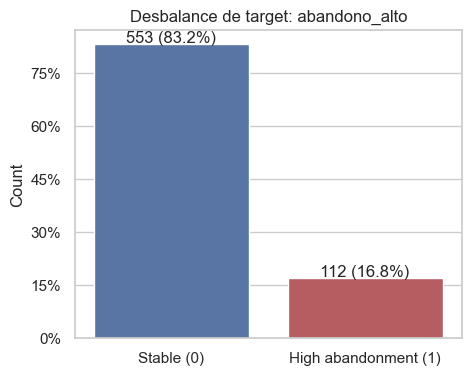


Conteos:
abandono_alto
0    553
1    112
Name: count, dtype: int64

Porcentajes:
Stable (0)              83.157895
High abandonment (1)    16.842105
dtype: float64


In [40]:
# Gráfica: desbalance del target
from matplotlib.ticker import PercentFormatter

counts = df['abandono_alto'].value_counts().sort_index()
labels = ['Stable (0)', 'High abandonment (1)']
vals = counts.values
pct = counts.values / counts.sum() * 100

plt.figure(figsize=(5,4))
sns.barplot(x=labels, y=vals, palette=['#4c72b0','#c44e52'])
for i, (v, p) in enumerate(zip(vals, pct)):
    plt.text(i, v + 3, f"{v} ({p:.1f}%)", ha='center')
plt.ylabel('Count')
plt.title('Desbalance de target: abandono_alto')
plt.gca().yaxis.set_major_formatter(PercentFormatter(counts.sum()))
plt.show()

print('\nConteos:')
print(counts)
print('\nPorcentajes:')
print(pd.Series(pct, index=labels))

### Falla 2 — Sparsity y ruido en features

Muchas variables tienen muchos ceros o varianza baja; esto limita la capacidad del modelo para aprender patrones. La siguiente celda muestra varianzas y boxplots para visualizar dispersión y outliers.

Features con varianza más baja (top 10):
n_usados            0.000000
n_yonques           0.000000
n_empenos           0.000000
TASA_SIN_BIENES     0.001341
TASA_SIN_ELEC       0.005835
TASA_SIN_DRENAJE    0.010941
TASA_1_CUARTO       0.014030
TASA_PISO_TIERRA    0.015709
TASA_LETRINA        0.019004
SCORE_REZAGO        0.034383
dtype: float64


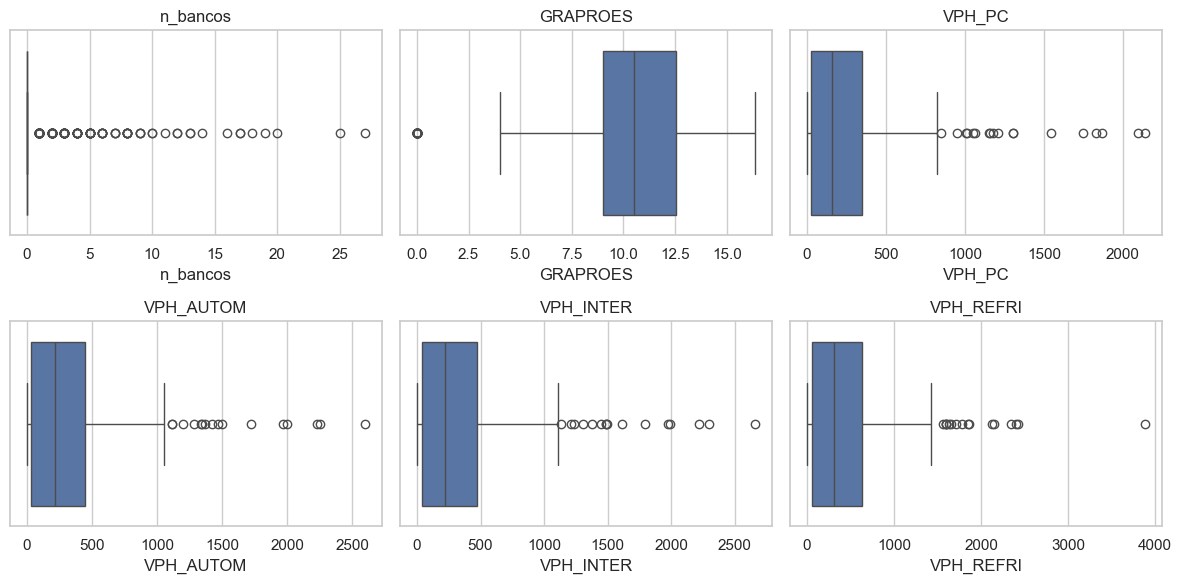


Porcentaje de ceros (top 10):
n_empenos           100.000000
n_usados            100.000000
n_yonques           100.000000
n_inmobiliarias      90.526316
TASA_SIN_DRENAJE     83.308271
TASA_SIN_ELEC        80.000000
TASA_LETRINA         78.947368
n_bancos             78.045113
TASA_SIN_BIENES      77.142857
n_cafes              62.857143
dtype: float64


In [41]:
# Varianzas y boxplots
variances = num_df[num_features].var().sort_values()
print('Features con varianza más baja (top 10):')
print(variances.head(10))

# Boxplot de las 6 features con mayor varianza para ver outliers
high_var = variances.tail(6).index.tolist()
plt.figure(figsize=(12,6))
for i, col in enumerate(high_var, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=num_df[col].dropna())
    plt.title(col)
plt.tight_layout()
plt.show()

# Mostrar % de ceros (ya calculado en zero_pct), print top 10
print('\nPorcentaje de ceros (top 10):')
print(zero_pct.sort_values(ascending=False).head(10))

### Falla 3 — Redundancia del catastral

El valor catastral añade poca información nueva (está correlacionado con proxies de bienestar). La siguiente celda muestra el coeficiente de correlación y un scatter plot que respalda la redundancia.

train_ready: (665, 22) | train_catastro: (665, 23)

Correlaciones VALOR_CATASTRAL_MAX vs VPH_* (ordenadas por |corr|):
VPH_PC       0.321
VPH_AUTOM    0.275
VPH_INTER    0.273
VPH_REFRI    0.222
Name: VALOR_CATASTRAL_MAX, dtype: float64


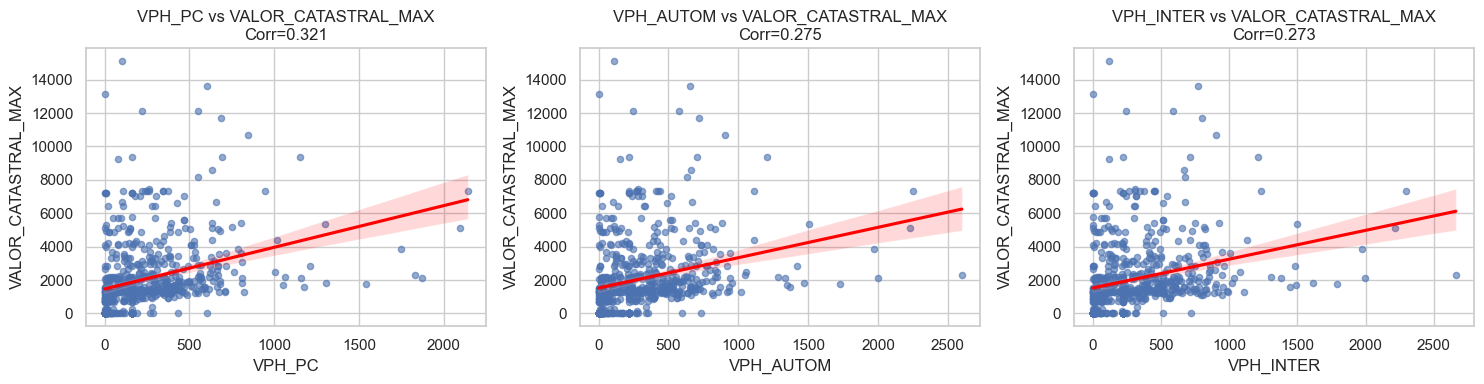

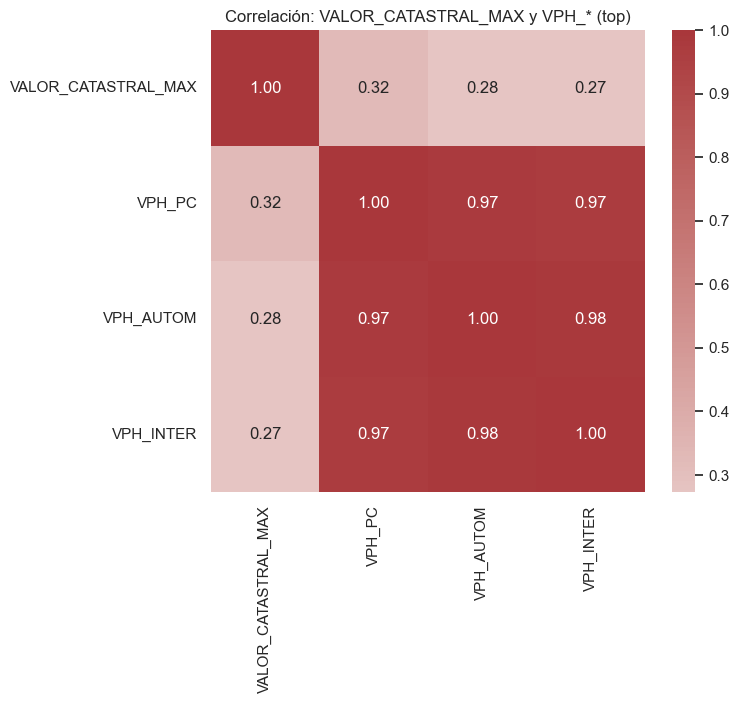


Primeras 6 filas (VALOR_CATASTRAL_MAX y top VPH):


,VALOR_CATASTRAL_MAX,VPH_PC,VPH_AUTOM,VPH_INTER
0,4115.0,0.0,0.0,0.0
1,833.0,159.0,218.0,223.0
2,0.0,53.0,64.0,58.0
3,3330.0,137.0,229.0,221.0
4,0.0,39.0,49.0,60.0
5,6415.0,295.0,335.0,313.0


In [45]:
print(f"train_ready: {df_ready.shape} | train_catastro: {df_catastro.shape}")

# Comprobar existencia de la columna catastral
assert 'VALOR_CATASTRAL_MAX' in df_catastro.columns, 'Falta VALOR_CATASTRAL_MAX en train_catastro.csv'

# Seleccionar columnas proxy de bienestar que empiezan por 'VPH'
vph_cols = [c for c in df_catastro.columns if c.upper().startswith('VPH')]
assert len(vph_cols) > 0, 'No se encontraron columnas que empiecen por VPH en train_catastro.csv'

# Calcular correlaciones entre VALOR_CATASTRAL_MAX y columnas VPH
corrs = df_catastro[[ 'VALOR_CATASTRAL_MAX'] + vph_cols].corr()['VALOR_CATASTRAL_MAX'].drop('VALOR_CATASTRAL_MAX')
print('\nCorrelaciones VALOR_CATASTRAL_MAX vs VPH_* (ordenadas por |corr|):')
print(corrs.abs().sort_values(ascending=False).round(3))

# Elegir las 3 VPH con mayor correlación absoluta para graficar
top_vph = corrs.abs().sort_values(ascending=False).head(3).index.tolist()

# Scatter + línea de regresión para cada top_VPH
plt.figure(figsize=(5 * len(top_vph), 4))
for i, col in enumerate(top_vph, 1):
    plt.subplot(1, len(top_vph), i)
    sns.regplot(x=col, y='VALOR_CATASTRAL_MAX', data=df_catastro, scatter_kws={'s':20, 'alpha':0.6}, line_kws={'color':'red'})
    r = df_catastro[col].corr(df_catastro['VALOR_CATASTRAL_MAX'])
    plt.title(f"{col} vs VALOR_CATASTRAL_MAX\nCorr={r:.3f}")
    plt.xlabel(col)
    plt.ylabel('VALOR_CATASTRAL_MAX')
plt.tight_layout()
plt.show()

# Heatmap de correlación entre VALOR_CATASTRAL_MAX y los top_vph
cols_heat = ['VALOR_CATASTRAL_MAX'] + top_vph
plt.figure(figsize=(4 + len(top_vph), 3 + len(top_vph)))
sns.heatmap(df_catastro[cols_heat].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlación: VALOR_CATASTRAL_MAX y VPH_* (top)')
plt.show()

# Mostrar ejemplos de filas para inspección rápida (primeras 6)
print('\nPrimeras 6 filas (VALOR_CATASTRAL_MAX y top VPH):')
display(df_catastro[['VALOR_CATASTRAL_MAX'] + top_vph].head(6))

### Conclusión breve

El modelo falla por tres razones principales: desbalance del target, features con alta esparsidad/ruido y redundancia de variables (catastro). Con los gráficos y métricas anteriores se confirma esta hipótesis.